# FARM WORKERS SHIFT AND SALARIES ANALYSIS

This works aims to analyze the attendance and salary data of farm employees working in morning and evening shifts. The goal is to derive insights into employee work patterns, shift preferences, salary distribution, and workforce optimization to improve farm operations.



## Import Libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [37]:
data = pd.read_csv("Farm Coolie.csv")

In [38]:
data.head()

,Date,Day,Morning Shift,Morning Shift Salary,Evening Shift,Evening Shift Salary
0,04-11-2024,Monday,NaN,NaN,Jaya,100.0
1,04-11-2024,Monday,NaN,NaN,Kala,100.0
2,04-11-2024,Monday,NaN,NaN,Muthu,100.0
3,05-11-2024,Tuesday,Dhanalakshmi,150.0,Dhanalakshmi,100.0
4,05-11-2024,Tuesday,NaN,NaN,Jaya,100.0


In [39]:
data.tail()

,Date,Day,Morning Shift,Morning Shift Salary,Evening Shift,Evening Shift Salary
79,28-11-2024,Tuesday,Kala,150.0,NaN,NaN
80,28-11-2024,Tuesday,Paapu,150.0,NaN,NaN
81,29-11-2024,Wednesday,Kala,150.0,NaN,NaN
82,29-11-2024,Wednesday,Paapu,150.0,NaN,NaN
83,29-11-2024,Wednesday,Dhanalakshmi,150.0,NaN,NaN


In [40]:
data.describe()

,Morning Shift Salary,Evening Shift Salary
count,39.0,74.0
mean,150.0,100.0
std,0.0,0.0
min,150.0,100.0
25%,150.0,100.0
50%,150.0,100.0
75%,150.0,100.0
max,150.0,100.0


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  84 non-null     object 
 1   Day                   84 non-null     object 
 2   Morning Shift         39 non-null     object 
 3   Morning Shift Salary  39 non-null     float64
 4   Evening Shift         74 non-null     object 
 5   Evening Shift Salary  74 non-null     float64
dtypes: float64(2), object(4)
memory usage: 4.1+ KB


In [42]:
data.isnull()

,Date,Day,Morning Shift,Morning Shift Salary,Evening Shift,Evening Shift Salary
0,False,False,True,True,False,False
1,False,False,True,True,False,False
2,False,False,True,True,False,False
3,False,False,False,False,False,False
4,False,False,True,True,False,False
...,...,...,...,...,...,...
79,False,False,False,False,True,True
80,False,False,False,False,True,True
81,False,False,False,False,True,True
82,False,False,False,False,True,True


In [43]:
data.columns = data.columns.str.strip()
data.columns

Index(['Date', 'Day', 'Morning Shift', 'Morning Shift Salary', 'Evening Shift',
       'Evening Shift Salary'],
      dtype='object')

In [44]:
# Convert 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], format="%d-%m-%Y")

## Filling missing values

In [45]:
# Fill missing salaries with 0 (here no salary for absent entries)
data['Morning Shift Salary'] = data['Morning Shift Salary'].fillna(0)
data['Evening Shift Salary'] = data['Evening Shift Salary'].fillna(0)

## 1. How much money is spent for workers for both Morning and Evening?

In [46]:
total_morning_salary = data['Morning Shift Salary'].sum()
total_evening_salary = data['Evening Shift Salary'].sum()

In [47]:
total_morning_salary

5850.0

In [48]:
total_evening_salary

7400.0

In [49]:
total_paid = total_morning_salary+total_evening_salary

In [50]:
total_paid

13250.0

## 2. Which employees only work specific shifts?

In [51]:

morning_only = set(data['Morning Shift'].unique()) - set(data['Evening Shift'].unique())
evening_only = set(data['Evening Shift'].unique()) - set(data['Morning Shift'].unique())
print("Employees Only in Morning Shifts:", morning_only)
print("Employees Only in Evening Shifts:", evening_only)

Employees Only in Morning Shifts: set()
Employees Only in Evening Shifts: {'Saraswathi', 'Muthu', 'Mala', 'Rani', 'Vijaya'}


## 3. Which worker earn more in Morning?

In [52]:
morning_top_earner = data.groupby('Morning Shift')['Morning Shift Salary'].sum().idxmax()
morning_top_salary = data.groupby('Morning Shift')['Morning Shift Salary'].sum().max()

In [53]:
morning_top_earner

'Paapu'

In [54]:
morning_top_salary

1950.0

## 4. Which worker earn more in Evening?

In [55]:
evening_top_earner = data.groupby('Evening Shift')['Evening Shift Salary'].sum().idxmax()
evening_top_salary = data.groupby('Evening Shift')['Evening Shift Salary'].sum().max()

In [56]:
evening_top_earner 

'Dhanalakshmi'

In [57]:
evening_top_salary

1600.0

## 5. Total days about the workers presence in the month

In [58]:
# Shift frequency analysis
morning_shift_counts = data['Morning Shift'].value_counts()
morning_shift_counts

Morning Shift
Paapu           13
Kala            11
Dhanalakshmi    10
Seetha           3
Jaya             2
Name: count, dtype: int64

In [59]:
evening_shift_counts = data['Evening Shift'].value_counts()
evening_shift_counts


Evening Shift
Dhanalakshmi    16
Kala            14
Paapu           14
Saraswathi      10
Jaya             9
Muthu            3
Seetha           3
Mala             2
Vijaya           2
Rani             1
Name: count, dtype: int64

## 6. Day with highest salary cost

In [60]:
salary_by_day = data.groupby('Day')[['Morning Shift Salary', 'Evening Shift Salary']].sum().sum(axis=1)
print("Day with Highest Salary Cost:", salary_by_day.idxmax())

Day with Highest Salary Cost: Tuesday


## 7. Salary distribution by shift

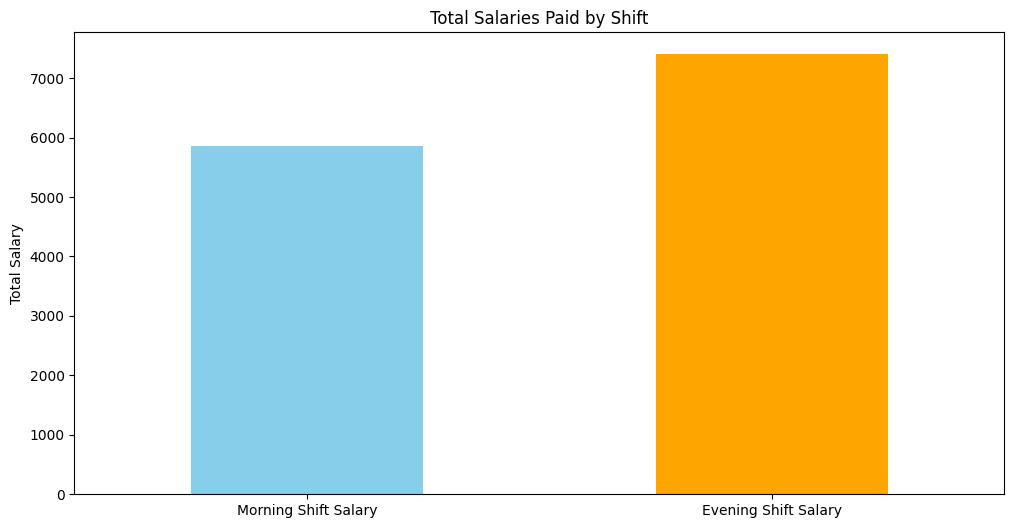

In [61]:
#bar chart
plt.figure(figsize=(12, 6))
data[['Morning Shift Salary', 'Evening Shift Salary']].sum().plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Total Salaries Paid by Shift")
plt.ylabel("Total Salary")
plt.xticks(rotation=0)
plt.show()

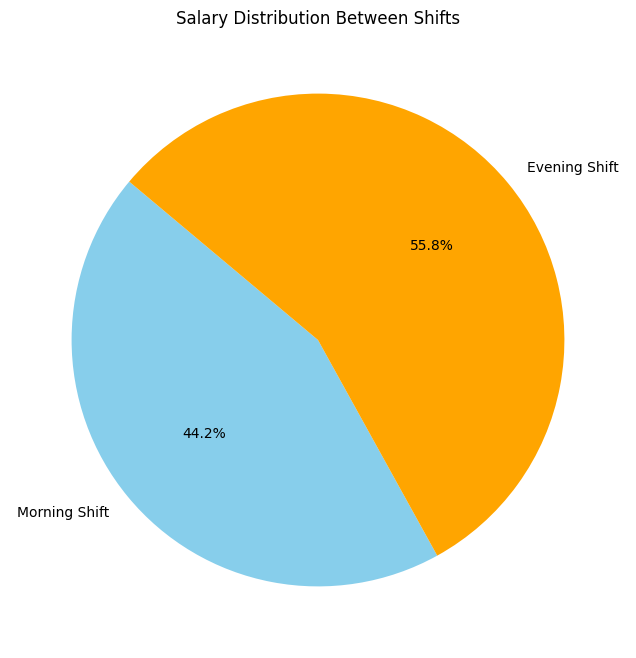

In [62]:
#pie chart
total_salaries = [total_morning_salary, total_evening_salary]
labels = ['Morning Shift', 'Evening Shift']
plt.figure(figsize=(8, 8))
plt.pie(total_salaries, labels=labels, autopct="%1.1f%%", colors=['skyblue', 'orange'], startangle=140)
plt.title("Salary Distribution Between Shifts")
plt.show()

## 8. Frequency of employees working shifts

C:\Users\Admin\AppData\Local\Temp\ipykernel_14084\3242542893.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=morning_shift_counts.index[:10], y=morning_shift_counts.values[:10], palette="viridis")


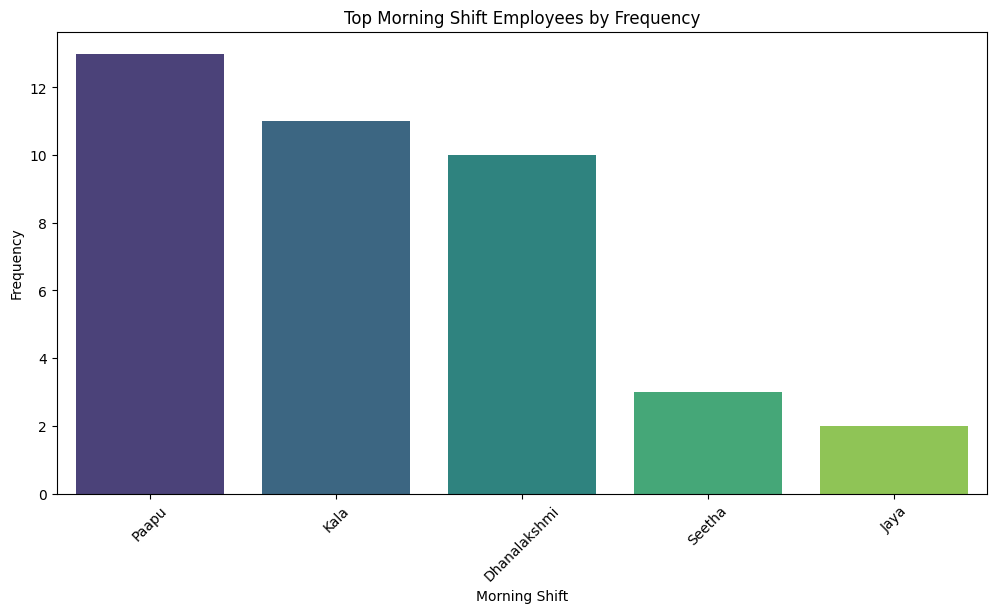

In [63]:
#morning shift
plt.figure(figsize=(12, 6))

sns.barplot(x=morning_shift_counts.index[:10], y=morning_shift_counts.values[:10], palette="viridis")
plt.title("Top Morning Shift Employees by Frequency")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14084\1680408585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=evening_shift_counts.index[:10], y=evening_shift_counts.values[:10], palette="magma")


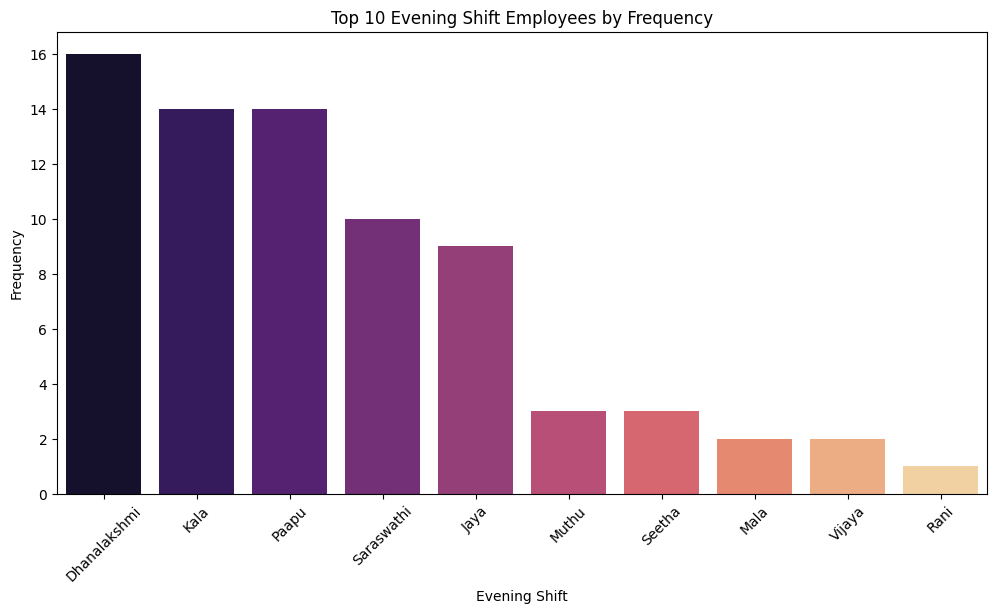

In [64]:
#evening shift
plt.figure(figsize=(12, 6))

sns.barplot(x=evening_shift_counts.index[:10], y=evening_shift_counts.values[:10], palette="magma")
plt.title("Top 10 Evening Shift Employees by Frequency")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14084\3861091091.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attendance_per_day.index, y=attendance_per_day.values, palette="magma")


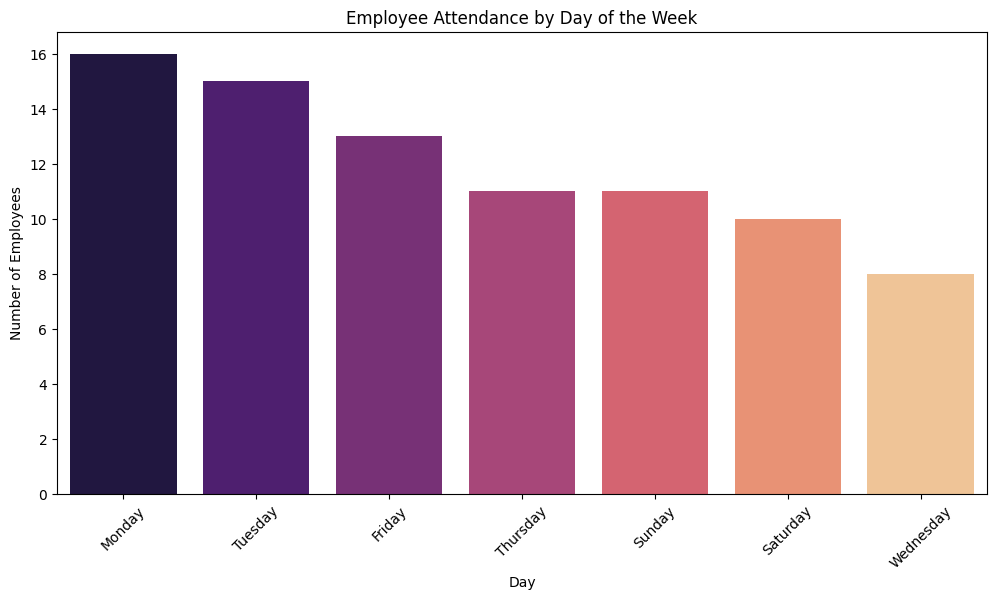

In [65]:
# Day-wise employee attendance
plt.figure(figsize=(12, 6))

attendance_per_day = data['Date'].dt.day_name().value_counts()
sns.barplot(x=attendance_per_day.index, y=attendance_per_day.values, palette="magma")
plt.title("Employee Attendance by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

## 9. Total Amount Spend for each shift and Who earn more in this month Details

In [66]:
print("Total Morning Shift Salary Paid:", total_morning_salary)
print("Total Evening Shift Salary Paid:", total_evening_salary)
print("Top Morning Shift Earner:", morning_top_earner, "with salary", morning_top_salary)
print("Top Evening Shift Earner:", evening_top_earner, "with salary", evening_top_salary)

Total Morning Shift Salary Paid: 5850.0
Total Evening Shift Salary Paid: 7400.0
Top Morning Shift Earner: Paapu with salary 1950.0
Top Evening Shift Earner: Dhanalakshmi with salary 1600.0


## Conclusion:

This provides a comprehensive analysis of farm employee shifts and salaries. By uncovering patterns and trends in attendance and salaries, the farm management can make informed decisions to enhance efficiency, reduce costs, and improve overall workforce satisfaction